In [ ]:
!pip install pandas
!pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


# 1 - Motivation
- what is your dataset?
- Why did you choose this data?
- What was your goal for the end users experience?

# 2 - Basic Stats
- Write about choices in datacleaning and preprocessing
- Write a short section discussin datasets stats containing key points/plot from exploratory data analysis

## 2.1 Data cleaning

In [ ]:
import pandas as pd
import openpyxl


df = pd.read_excel("data/smileystatus.xlsx")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58396 entries, 0 to 58395
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   navnelbnr                   58396 non-null  int64         
 1   cvrnr                       57304 non-null  float64       
 2   pnr                         57040 non-null  float64       
 3   brancheKode                 58396 non-null  str           
 4   branche                     58396 non-null  str           
 5   virksomhedstype             58396 non-null  str           
 6   navn1                       58396 non-null  str           
 7   adresse1                    58396 non-null  str           
 8   postnr                      58396 non-null  int64         
 9   By                          57468 non-null  str           
 10  seneste_kontrol             51847 non-null  float64       
 11  seneste_kontrol_dato        51849 non-null  datetime64[us]
 12  n

In [ ]:
df.shape

(58396, 23)

In [ ]:
# Start by unpivoting so one kontrol per line
df = df.rename(columns={
    "seneste_kontrol": "kontrol_1",
    "seneste_kontrol_dato": "dato_1",
    "naestseneste_kontrol": "kontrol_2",
    "naestseneste_kontrol_dato": "dato_2",
    "tredjeseneste_kontrol": "kontrol_3",
    "tredjeseneste_kontrol_dato": "dato_3",
    "fjerdeseneste_kontrol": "kontrol_4",
    "fjerdeseneste_kontrol_dato": "dato_4"
})

df = (
    pd.wide_to_long(
        df,
        stubnames=["kontrol", "dato"],
        i="navnelbnr",
        j="tjek_nr",
        sep="_"
    )
    .reset_index()
)

df = df.dropna(subset=["kontrol", "dato"])
df["dato"] = pd.to_datetime(df["dato"])


In [ ]:
# Next we will remove columns that we wont be using
df = df.drop(columns=['Elite_Smiley', 'brancheKode', 'reklame_beskyttelse'])

df.head()

,navnelbnr,tjek_nr,By,Geo_Lat,Geo_Lng,URL,adresse1,branche,cvrnr,navn1,pnr,postnr,virksomhedstype,kontrol,dato
0,513605,1,København SV,55.656613,12.537889,http://www.findsmiley.dk/da-DK/Searching/Detai...,Enghavevej 172,Specialforretning - Bager m.v.,34583730.0,Firdaws ApS,1.017699e+09,2450,Detail,1.0,2024-09-27
1,26029,1,Brønderslev,57.270705,9.950767,http://www.findsmiley.dk/da-DK/Searching/Detai...,Dannebrogsgade 21,Specialforretning - Bager m.v.,18043041.0,KonditorBager,1.001418e+09,9700,Detail,1.0,2022-05-03
2,69750,1,Give,55.844766,9.237281,http://www.findsmiley.dk/da-DK/Searching/Detai...,Nytorv 1,Specialforretning - Bager m.v.,21467782.0,NYTORVS BAGERI APS,1.004954e+09,7323,Detail,1.0,2025-01-16
3,555571,1,Havdrup,55.543675,12.115530,http://www.findsmiley.dk/da-DK/Searching/Detai...,Møllemarken 6,Specialforretning - Bager m.v.,18623978.0,SuperBrugsen Havdrup Bageri,1.019633e+09,4622,Detail,1.0,2025-04-08
4,1292639,1,Højer,NaN,NaN,http://www.findsmiley.dk/da-DK/Searching/Detai...,Storegade 20 stuen,Specialforretning - Bager m.v.,43771930.0,Digebageren,1.028920e+09,6280,Detail,1.0,2025-01-28


In [ ]:
# Check value counts for each control

print("Now lets look at the distribution between different controls")
print(df.groupby("kontrol")["branche"].size())

# There are two instances with 0,9 rating that does not make sense, we remove that
df = df[df["kontrol"] != 0.0]
df.groupby("kontrol")["branche"].size()

Now lets look at the distribution between different controls
kontrol
0.0         2
1.0    153464
2.0     12016
3.0       370
4.0      1741
Name: branche, dtype: int64


kontrol
1.0    153464
2.0     12016
3.0       370
4.0      1741
Name: branche, dtype: int64

In [ ]:
# Now lets look at the distribution of dates
df["dato"] = pd.to_datetime(df["dato"])

print(df.groupby(df["dato"].dt.year)["kontrol"].size())


dato
2003        1
2004       82
2005      145
2006      231
2007      296
2008      247
2009      334
2010      334
2011      443
2012      387
2013      519
2014      938
2015     1376
2016     2680
2017     3977
2018     6541
2019     9200
2020     6443
2021    10485
2022    16200
2023    25162
2024    31777
2025    37403
2026    12390
Name: kontrol, dtype: int64


We will remove everything before 2012 as that's when they started using this dataset for real [(Link to reference)](https://www.findsmiley.dk/om_smiley/info_til_forbrugere/Sider/Generelt/Alle_kontrolrapporter_paa_nettet.aspx?utm_source=chatgpt.com&fbclid=IwY2xjawRa5lJleHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEeXMWmZ1Du6p8SP3usvCDV5Y3jXcsoGSyst-WYIBGZQxFMrjBumI8SGEAIasU_aem_tnBQ9L4HC8EORInlDwAH9Q)

In [ ]:
# We see that the number of control inspections are increasing with every year, with a slight dip 2007

# We will remove everything before 2012 (heimil hér fyrir ofan)
# This dataset only includes the last four inspections for each establishment, that is why there are so many inspections in the last years but decrease 
df = df[df["dato"].dt.year >= 2012]

print(df.groupby(df["dato"].dt.year)["kontrol"].size())

dato
2012      387
2013      519
2014      938
2015     1376
2016     2680
2017     3977
2018     6541
2019     9200
2020     6443
2021    10485
2022    16200
2023    25162
2024    31777
2025    37403
2026    12390
Name: kontrol, dtype: int64


In [ ]:
# Now lets look at categories of restaurants
print(f'There are {len(df["branche"].unique())} unique branches in this dataset')

# Lets look at how many inspections are in each branche
df["branche"].value_counts()

print(df["branche"].unique())

There are 54 unique branches in this dataset
<StringArray>
[                              'Specialforretning - Bager m.v.',
           'Dagligvareforretning uden/med begrænset behandling',
           'Markedsføring af fødevarekontaktmaterialer, engros',
            'Fremstilling af fødevarekontaktmaterialer, engros',
                     'Håndtering af levende toskallede bløddyr',
 'Fremstilling af animalske produkter - Fisk og muslinger m.v.',
                                'Specialforretning - Fisk m.v.',
 'Lager og evt. engroshandel med salg til detailvirksomheder (',
       'Lager/lagerhotel og evt. engroshandel - Uden køl/frost',
        'Lager/lagerhotel og evt. engroshandel - Med køl/frost',
             'Frysehuse med indfrysning af animalske produkter',
             'Serveringsvirksomhed - Institutionskøkkener m.v.',
 'Catering med levering til detailvirksomheder (detail med eng',
            'Fremstilling af fødevarekontaktmaterialer, detail',
           'Markedsføring af fø

In [ ]:
# We will start by grouping categories
# For that we got the help of LLMs

category_group_map = {
    # ── 1. Production & Manufacturing ──────────────────────────────────────
    "Fremstilling af animalske produkter - Kød":                    "Production & Manufacturing",
    "Fremstilling af animalske produkter - Mælk og ost":            "Production & Manufacturing",
    "Fremstilling af animalske produkter - Æg":                     "Production & Manufacturing",
    "Fremstilling af animalske produkter - Fisk og muslinger m.v.": "Production & Manufacturing",
    "Fremstilling af animalske produkter - Andre produkter":        "Production & Manufacturing",
    "Fremstilling af vegetabilske produkter mv. evt. med indhold":  "Production & Manufacturing",
    "Fremstilling af drikkevarer m.v.":                             "Production & Manufacturing",
    "Fremstilling af kosttilskud, tilsætningsstoffer m.v.":        "Production & Manufacturing",
    "Slagterier":                                                   "Production & Manufacturing",
    "Slagtebusser":                                                 "Production & Manufacturing",

    # ── 2. Retail & Shops ──────────────────────────────────────────────────
    "Specialforretning - Bager m.v.":                               "Retail & Shops",
    "Specialforretning - Fisk m.v.":                                "Retail & Shops",
    "Specialforretning - Slagter m.v.":                             "Retail & Shops",
    "Specialforretning - Delikatesse, specialiteter m.v. med beha": "Retail & Shops",
    "Dagligvareforretning uden/med begrænset behandling":           "Retail & Shops",

    # ── 3. Restaurants & Food Service ─────────────────────────────────────
    "Serveringsvirksomhed - Restauranter m.v.":                     "Restaurants & Food Service",
    "Serveringsvirksomhed - Institutionskøkkener m.v.":             "Restaurants & Food Service",
    "Serveringsvirksomhed - Uden behandling":                       "Restaurants & Food Service",
    "Catering med levering til detailvirksomheder (detail med eng":  "Restaurants & Food Service",

    # ── 4. Storage, Logistics & Transport ─────────────────────────────────
    "Lager/lagerhotel og evt. engroshandel - Med køl/frost":        "Storage, Logistics & Transport",
    "Lager/lagerhotel og evt. engroshandel - Uden køl/frost":       "Storage, Logistics & Transport",
    "Lager og evt. engroshandel med salg til detailvirksomheder (": "Storage, Logistics & Transport",
    "Frysehuse med indfrysning af animalske produkter":             "Storage, Logistics & Transport",
    "Transportvirksomhed, engros":                                  "Storage, Logistics & Transport",
    "Transportvirksomhed, detail":                                  "Storage, Logistics & Transport",

    # ── 5. Wholesale & Food Contact Materials ─────────────────────────────
    "Markedsføring af fødevarekontaktmaterialer, engros":           "Wholesale & Food Contact Materials",
    "Fremstilling af fødevarekontaktmaterialer, engros":            "Wholesale & Food Contact Materials",
    "Fremstilling af fødevarekontaktmaterialer, detail":            "Wholesale & Food Contact Materials",
    "Markedsføring af fødevarekontaktmaterialer, detail":           "Wholesale & Food Contact Materials",

    # ── 6. Specialized / High-risk Regulated ──────────────────────────────
    "Håndtering af levende toskallede bløddyr":                     "Specialized / High-risk Regulated",
    "Kvindemælkscentraler (detail med engros)":                     "Specialized / High-risk Regulated",
    "Kontorvirksomhed eller agenturvirksomhed - uden lager":        "Specialized / High-risk Regulated",
    "Kædekontrolhovedkontor - Fødevarer":                           "Specialized / High-risk Regulated",

    # ── 7. Preliminary Registrations ──────────────────────────────────────
    "Virksomhed, foreløbig: Engroshandel og/eller lager/lagerhote": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill./pakn. af tils.stoff., kost": "Preliminary Registrations",
    "Virksomhed, foreløbig: Transportvirksomhed, engros":           "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill./pakn. af konfekture, sukke": "Preliminary Registrations",
    "Virksomhed, foreløbig AUT: Slagteri, slagteri med fremstilli": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill. af bagværk, brød, pasta o.": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill./pakn. af drikkev., maltfab": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill. af fødevarekontaktmaterial": "Preliminary Registrations",
    "Virksomhed, foreløbig AUT: Fremstill./pakn. primært ud fra m": "Preliminary Registrations",
    "Virksomhed, foreløbig: Internethandel, udelukkende salg og m": "Preliminary Registrations",
    "Virksomhed, foreløbig: Detailforr. m. beh., fx mikrobryggeri": "Preliminary Registrations",
    "Virksomhed, foreløbig: Smørrebrødsforr., delikatesseafd., ta": "Preliminary Registrations",
    "Virksomhed, foreløbig: Butikshandel, fx kiosk, apotek, helse": "Preliminary Registrations",
    "Virksomhed, foreløbig: Institutionskøkken, fx børneinstituti": "Preliminary Registrations",
    "Virksomhed, foreløbig: Restaurant, pizzeria, cafe, kantine,":  "Preliminary Registrations",
    "Virksomhed, foreløbig: Butikshandel, fx dagligvareforr., grø": "Preliminary Registrations",
    "Virksomhed, foreløbig: Mobil virksomh.(fx salg af br. mandl.": "Preliminary Registrations",
    "Virksomhed, foreløbig: Bagerforretning, bagerafdeling, kondi": "Preliminary Registrations",
    "Virksomhed, foreløbig: Servering, fx værtshus, vinbar, autom": "Preliminary Registrations",
    "Virksomhed, foreløbig: Slagter, slagterafdeling":             "Preliminary Registrations",
    "Virksomhed, foreløbig: Kontorvirksomhed (fødevarer og/eller": "Preliminary Registrations",
}

# Apply to your dataframe — replace 'branche' with your actual column name
df["category_group"] = df["branche"].map(category_group_map)

# Flag preliminary registrations as a boolean for easy filtering
df["is_preliminary"] = df["branche"].str.startswith("Virksomhed, foreløbig")

# Sanity check — see if any categories didn't get mapped
unmapped = df[df["category_group"].isna()]["branche"].unique()
if len(unmapped):
    print("Unmapped categories:", unmapped)
    
# Then we will translate the categories 
    
category_name_en = {
    # Animal products
    "Fremstilling af animalske produkter - Kød":                    "Production of animal products - Meat",
    "Fremstilling af animalske produkter - Mælk og ost":            "Production of animal products - Milk and cheese",
    "Fremstilling af animalske produkter - Æg":                     "Production of animal products - Eggs",
    "Fremstilling af animalske produkter - Fisk og muslinger m.v.": "Production of animal products - Fish and shellfish",
    "Fremstilling af animalske produkter - Andre produkter":        "Production of animal products - Other products",

    # Other production
    "Fremstilling af vegetabilske produkter mv. evt. med indhold":  "Production of vegetable products (incl. mixed content)",
    "Fremstilling af drikkevarer m.v.":                             "Production of beverages",
    "Fremstilling af kosttilskud, tilsætningsstoffer m.v.":        "Production of dietary supplements and additives",
    "Slagterier":                                                   "Slaughterhouses",
    "Slagtebusser":                                                 "Mobile slaughter units",

    # Retail
    "Specialforretning - Bager m.v.":                               "Specialty shop - Bakery",
    "Specialforretning - Fisk m.v.":                                "Specialty shop - Fish",
    "Specialforretning - Slagter m.v.":                             "Specialty shop - Butcher",
    "Specialforretning - Delikatesse, specialiteter m.v. med beha": "Specialty shop - Delicatessen and specialties",
    "Dagligvareforretning uden/med begrænset behandling":           "Grocery store (with or without limited processing)",

    # Food service
    "Serveringsvirksomhed - Restauranter m.v.":                     "Food service - Restaurants",
    "Serveringsvirksomhed - Institutionskøkkener m.v.":             "Food service - Institutional kitchens",
    "Serveringsvirksomhed - Uden behandling":                       "Food service - No food processing",
    "Catering med levering til detailvirksomheder (detail med eng":  "Catering with delivery to retail businesses",

    # Storage & transport
    "Lager/lagerhotel og evt. engroshandel - Med køl/frost":        "Warehouse / storage hotel with refrigeration or freezing",
    "Lager/lagerhotel og evt. engroshandel - Uden køl/frost":       "Warehouse / storage hotel without refrigeration",
    "Lager og evt. engroshandel med salg til detailvirksomheder (": "Warehouse and wholesale with retail sales",
    "Frysehuse med indfrysning af animalske produkter":             "Cold store with freezing of animal products",
    "Transportvirksomhed, engros":                                  "Transport company - Wholesale",
    "Transportvirksomhed, detail":                                  "Transport company - Retail",

    # Food contact materials
    "Markedsføring af fødevarekontaktmaterialer, engros":           "Marketing of food contact materials - Wholesale",
    "Fremstilling af fødevarekontaktmaterialer, engros":            "Production of food contact materials - Wholesale",
    "Fremstilling af fødevarekontaktmaterialer, detail":            "Production of food contact materials - Retail",
    "Markedsføring af fødevarekontaktmaterialer, detail":           "Marketing of food contact materials - Retail",

    # Specialized
    "Håndtering af levende toskallede bløddyr":                     "Handling of live bivalve molluscs",
    "Kvindemælkscentraler (detail med engros)":                     "Human milk banks",
    "Kontorvirksomhed eller agenturvirksomhed - uden lager":        "Office or agency business - No warehouse",
    "Kædekontrolhovedkontor - Fødevarer":                           "Chain control head office - Food",

    # Preliminary registrations
    "Virksomhed, foreløbig: Engroshandel og/eller lager/lagerhote": "Preliminary: Wholesale and/or warehouse",
    "Virksomhed, foreløbig: Fremstill./pakn. af tils.stoff., kost": "Preliminary: Production/packaging of additives and supplements",
    "Virksomhed, foreløbig: Transportvirksomhed, engros":           "Preliminary: Transport company - Wholesale",
    "Virksomhed, foreløbig: Fremstill./pakn. af konfekture, sukke": "Preliminary: Production/packaging of confectionery and sugar",
    "Virksomhed, foreløbig AUT: Slagteri, slagteri med fremstilli": "Preliminary (auth): Slaughterhouse with production",
    "Virksomhed, foreløbig: Fremstill. af bagværk, brød, pasta o.": "Preliminary: Production of baked goods, bread and pasta",
    "Virksomhed, foreløbig: Fremstill./pakn. af drikkev., maltfab": "Preliminary: Production/packaging of beverages and malt",
    "Virksomhed, foreløbig: Fremstill. af fødevarekontaktmaterial": "Preliminary: Production of food contact materials",
    "Virksomhed, foreløbig AUT: Fremstill./pakn. primært ud fra m": "Preliminary (auth): Production/packaging primarily from milk",
    "Virksomhed, foreløbig: Internethandel, udelukkende salg og m": "Preliminary: Online retail only",
    "Virksomhed, foreløbig: Detailforr. m. beh., fx mikrobryggeri": "Preliminary: Retail with processing (e.g. microbrewery)",
    "Virksomhed, foreløbig: Smørrebrødsforr., delikatesseafd., ta": "Preliminary: Smørrebrød shop, deli or takeaway",
    "Virksomhed, foreløbig: Butikshandel, fx kiosk, apotek, helse": "Preliminary: Retail shop (e.g. kiosk, pharmacy, health store)",
    "Virksomhed, foreløbig: Institutionskøkken, fx børneinstituti": "Preliminary: Institutional kitchen (e.g. daycare, school)",
    "Virksomhed, foreløbig: Restaurant, pizzeria, cafe, kantine,":  "Preliminary: Restaurant, pizzeria, café or canteen",
    "Virksomhed, foreløbig: Butikshandel, fx dagligvareforr., grø": "Preliminary: Retail shop (e.g. grocery, greengrocer)",
    "Virksomhed, foreløbig: Mobil virksomh.(fx salg af br. mandl.": "Preliminary: Mobile business (e.g. roasted nuts vendor)",
    "Virksomhed, foreløbig: Bagerforretning, bagerafdeling, kondi": "Preliminary: Bakery or confectionery shop",
    "Virksomhed, foreløbig: Servering, fx værtshus, vinbar, autom": "Preliminary: Serving venue (e.g. pub, wine bar, vending)",
    "Virksomhed, foreløbig: Slagter, slagterafdeling":             "Preliminary: Butcher or butcher department",
    "Virksomhed, foreløbig: Kontorvirksomhed (fødevarer og/eller": "Preliminary: Office business (food and/or other)",
}

# Apply both mappings to your dataframe
df["category_group"]   = df["branche"].map(category_group_map)
df["category"] = df["branche"].map(category_name_en)
df["is_preliminary"]   = df["branche"].str.startswith("Virksomhed, foreløbig")

# Sanity check
unmapped = df[df["category"].isna()]["branche"].unique()
if len(unmapped):
    print("Unmapped categories:", unmapped)


In [ ]:
df = df.drop(columns="branche")

In [ ]:
df.head()

,navnelbnr,tjek_nr,By,Geo_Lat,Geo_Lng,URL,adresse1,cvrnr,navn1,pnr,postnr,virksomhedstype,kontrol,dato,category_group,is_preliminary,category
0,513605,1,København SV,55.656613,12.537889,http://www.findsmiley.dk/da-DK/Searching/Detai...,Enghavevej 172,34583730.0,Firdaws ApS,1.017699e+09,2450,Detail,1.0,2024-09-27,Retail & Shops,False,Specialty shop - Bakery
1,26029,1,Brønderslev,57.270705,9.950767,http://www.findsmiley.dk/da-DK/Searching/Detai...,Dannebrogsgade 21,18043041.0,KonditorBager,1.001418e+09,9700,Detail,1.0,2022-05-03,Retail & Shops,False,Specialty shop - Bakery
2,69750,1,Give,55.844766,9.237281,http://www.findsmiley.dk/da-DK/Searching/Detai...,Nytorv 1,21467782.0,NYTORVS BAGERI APS,1.004954e+09,7323,Detail,1.0,2025-01-16,Retail & Shops,False,Specialty shop - Bakery
3,555571,1,Havdrup,55.543675,12.115530,http://www.findsmiley.dk/da-DK/Searching/Detai...,Møllemarken 6,18623978.0,SuperBrugsen Havdrup Bageri,1.019633e+09,4622,Detail,1.0,2025-04-08,Retail & Shops,False,Specialty shop - Bakery
4,1292639,1,Højer,NaN,NaN,http://www.findsmiley.dk/da-DK/Searching/Detai...,Storegade 20 stuen,43771930.0,Digebageren,1.028920e+09,6280,Detail,1.0,2025-01-28,Retail & Shops,False,Specialty shop - Bakery


## 2.2 Basic

In [ ]:
# hver er dreifingin almennt
import matplotlib.pyplot as plt
import seaborn as sns


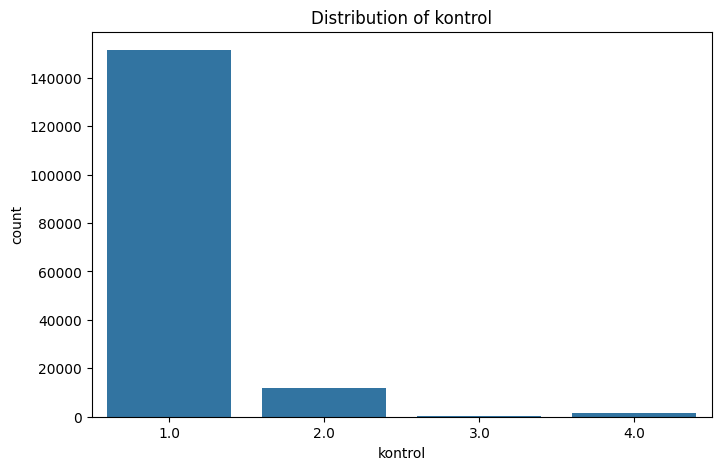

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="kontrol", data=df)
plt.title("Distribution of kontrol")
plt.show()



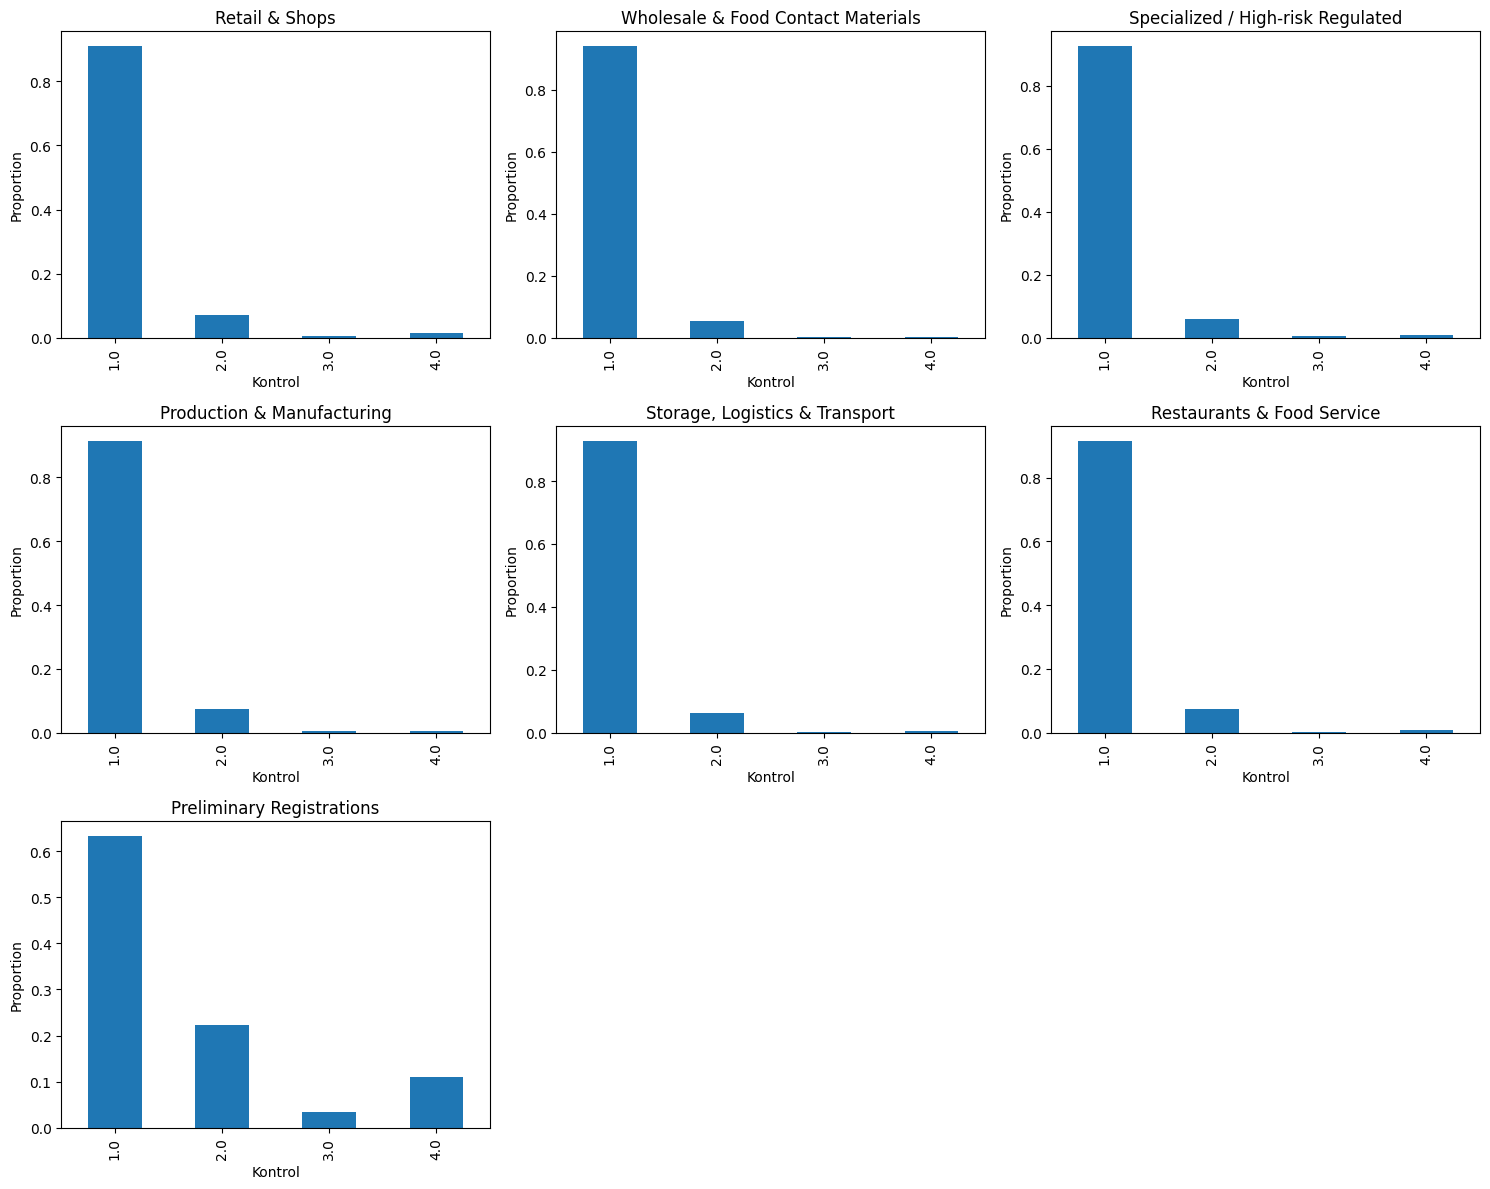

In [ ]:
import math

group_col = "category_group"
control_col = "kontrol"

groups = df[group_col].dropna().unique()

n = len(groups)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows*4))
axes = axes.flatten()

for i, group in enumerate(groups):
    subset = df[df[group_col] == group]

    (
        subset[control_col]
        .value_counts(normalize=True)
        .sort_index()
        .plot(kind="bar", ax=axes[i])
    )

    axes[i].set_title(group)
    axes[i].set_xlabel("Kontrol")
    axes[i].set_ylabel("Proportion")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
len(df[df["Geo_Lat"].isna()])

55211

In [ ]:
import math

group_col = "By"
control_col = "kontrol"

groups = df[group_col].dropna().unique()

n = len(groups)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows*4))
axes = axes.flatten()

for i, group in enumerate(groups):
    subset = df[df[group_col] == group]

    (
        subset[control_col]
        .value_counts(normalize=True)
        .sort_index()
        .plot(kind="bar", ax=axes[i])
    )

    axes[i].set_title(group)
    axes[i].set_xlabel("Kontrol")
    axes[i].set_ylabel("Proportion")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# dreifing miðað við grúbbur

In [ ]:
import json

# ── Build pairs ───────────────────────────────────────────────────────────
_sorted = df.sort_values(['navnelbnr', 'tjek_nr'], ascending=[True, False]).copy()
_sorted['follow_up_kontrol'] = _sorted.groupby('navnelbnr')['kontrol'].shift(-1)
pairs = _sorted.dropna(subset=['follow_up_kontrol']).copy()

# ── Overall stats ─────────────────────────────────────────────────────────
bad = pairs[pairs['kontrol'] > 1].copy()
bad['fully_fixed']    = bad['follow_up_kontrol'] == 1.0
bad['any_improvement'] = bad['follow_up_kontrol'] < bad['kontrol']

n_bad     = len(bad)
n_fixed   = int(bad['fully_fixed'].sum())
n_improved = int(bad['any_improvement'].sum()) - n_fixed
n_worse   = n_bad - n_fixed - n_improved

print("── Overall (all bad inspections) ────────────────────────")
print(f"  Total bad inspections with follow-up : {n_bad:,}")
print(f"  Fully fixed (→ no remarks)           : {n_fixed:,}  ({n_fixed/n_bad:.1%})")
print(f"  Partially improved                   : {n_improved:,}   ({n_improved/n_bad:.1%})")
print(f"  Same or worse                        : {n_worse:,}  ({n_worse/n_bad:.1%})")
print()

# ── Per-grade stats ───────────────────────────────────────────────────────
grade_meta = {
    2.0: {'bg': '#FEF9C3', 'color': '#854D0E', 'border': '#FDE047'},
    3.0: {'bg': '#FFEDD5', 'color': '#9A3412', 'border': '#FB923C'},
    4.0: {'bg': '#FEE2E2', 'color': '#991B1B', 'border': '#FCA5A5'},
}

name = {1.0: 'No remarks', 2.0: 'Instruction', 3.0: 'Injunction', 4.0: 'Serious'}

grades_data = []
print("── Per grade ─────────────────────────────────────────────")
for start in [2.0, 3.0, 4.0]:
    subset = pairs[pairs['kontrol'] == start]
    n      = len(subset)
    meta   = grade_meta[start]

    n_fix = int((subset['follow_up_kontrol'] == 1.0).sum())
    n_imp = int((subset['follow_up_kontrol'] < start).sum()) - n_fix
    n_sta = n - n_fix - n_imp

    print(f"  Grade {int(start)} ({name[start]:<13})  n={n:,}")
    print(f"    Fully fixed      : {n_fix:,}  ({n_fix/n:.1%})")
    print(f"    Partially improved: {n_imp:,}   ({n_imp/n:.1%})")
    print(f"    Same or worse    : {n_sta:,}  ({n_sta/n:.1%})")
    print()

    grades_data.append({
        'label':    f'Grade {int(start)}',
        'n':        n,
        'bg':       meta['bg'],
        'color':    meta['color'],
        'border':   meta['border'],
        'fixed':    n_fix,
        'improved': n_imp,
        'worse':    n_sta,
    })

# ── Print JS-ready data to paste into the HTML file ──────────────────────
print("── JS data for inspection_chart.html ────────────────────")
print("// Paste into const grades = [...] in the HTML <script> block:")
print()
js_grades = []
for g in grades_data:
    js_grades.append(
        f"  {{ label:'{g['label']}', n:{g['n']}, "
        f"bg:'{g['bg']}', color:'{g['color']}', border:'{g['border']}', "
        f"fixed:{g['fixed']}, improved:{g['improved']}, worse:{g['worse']} }},"
    )
print("const grades = [")
for line in js_grades:
    print(line)
print("];")
print()
print("// Paste into const overall = {{...}} in the HTML <script> block:")
print(f"const overall = {{ fixed:{n_fixed}, improved:{n_improved}, worse:{n_worse}, total:{n_bad} }};")

── Overall (all bad inspections) ────────────────────────
  Total bad inspections with follow-up : 12,972
  Fully fixed (→ no remarks)           : 11,513  (88.8%)
  Partially improved                   : 98   (0.8%)
  Same or worse                        : 1,361  (10.5%)

── Per grade ─────────────────────────────────────────────
  Grade 2 (Instruction  )  n=11,039
    Fully fixed      : 9,878  (89.5%)
    Partially improved: 0   (0.0%)
    Same or worse    : 1,161  (10.5%)

  Grade 3 (Injunction   )  n=327
    Fully fixed      : 262  (80.1%)
    Partially improved: 13   (4.0%)
    Same or worse    : 52  (15.9%)

  Grade 4 (Serious      )  n=1,606
    Fully fixed      : 1,373  (85.5%)
    Partially improved: 85   (5.3%)
    Same or worse    : 148  (9.2%)

── JS data for inspection_chart.html ────────────────────
// Paste into const grades = [...] in the HTML <script> block:

const grades = [
  { label:'Grade 2', n:11039, bg:'#FEF9C3', color:'#854D0E', border:'#FDE047', fixed:9878, impr

# 3 - Data Analysis
- Describe analysis and explain what you have learned
- Talk about machine learning if relevant

# 4 - Genre 
- Which tools did you use for visual narrative and why?
- Which ... for narrative structure and why?

# 5 - Visualizations
- Explain the visualizations chosen
- Why are they right for the story we want to tell

# 6 - Discussion
- what went well
- what is missing and could be improved
- and why

# 7 - Contributions
- NOT okay that all contributed equally..

In [ ]:
df_long["By"].value_counts().head(20)

NameError: name 'df_long' is not defined

In [ ]:
df_long["dato"] = pd.to_datetime(df_long["dato"])

df_long.groupby(df_long["dato"].dt.year)["kontrol"].mean()

dato
2003    1.000000
2004    1.146341
2005    1.089655
2006    1.064935
2007    1.060811
2008    1.028340
2009    1.023952
2010    1.026946
2011    1.045147
2012    1.036176
2013    1.059730
2014    1.038380
2015    1.041424
2016    1.023507
2017    1.026653
2018    1.035010
2019    1.040000
2020    1.032438
2021    1.043300
2022    1.049136
2023    1.067205
2024    1.114922
2025    1.192092
2026    1.240839
Name: kontrol, dtype: float64

In [ ]:
df_long.groupby("branche")["kontrol"].mean().sort_values()

branche
Virksomhed, foreløbig: Slagter, slagterafdeling                 1.000000
Virksomhed, foreløbig: Mobil virksomh.(fx salg af br. mandl.    1.000000
Virksomhed, foreløbig: Institutionskøkken, fx børneinstituti    1.000000
Virksomhed, foreløbig: Fremstill./pakn. af drikkev., maltfab    1.000000
Virksomhed, foreløbig: Bagerforretning, bagerafdeling, kondi    1.000000
Virksomhed, foreløbig AUT: Slagteri, slagteri med fremstilli    1.000000
Virksomhed, foreløbig: Smørrebrødsforr., delikatesseafd., ta    1.000000
Kvindemælkscentraler (detail med engros)                        1.000000
Håndtering af levende toskallede bløddyr                        1.000000
Fremstilling af fødevarekontaktmaterialer, engros               1.023227
Slagterier                                                      1.038217
Catering med levering til detailvirksomheder (detail med eng    1.049498
Lager og evt. engroshandel med salg til detailvirksomheder (    1.056657
Fremstilling af fødevarekontaktmaterialer, 

In [ ]:
df_long.groupby("By")["kontrol"].mean().sort_values(ascending=False).head(10)

By
Havndal         1.292683
Bevtoft         1.285714
Vandel          1.285714
Torrig L        1.275862
Åbyhøj          1.273859
Gandrup         1.272727
Bylderup Bov    1.250000
Tranbjerg J     1.250000
Tylstrup        1.232558
Brabrand        1.222764
Name: kontrol, dtype: float64